In [30]:
import pandas as pd
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
rd = Path.cwd().parent/'data'/'processed'
wd = Path.cwd().parent/'reports'


In [3]:
nav= pd.read_csv(rd/'clean_nav.csv')
nav['date'] = pd.to_datetime(nav['date'])

nav = nav.sort_values(
    ['amfi_code','date']
)

In [4]:
nav['daily_return'] = (
    nav.groupby('amfi_code')['nav']
       .pct_change()
)

In [5]:
results = []

for fund, grp in nav.groupby('amfi_code'):

    returns = grp['daily_return'].dropna()

    var95 = returns.quantile(0.05)

    cvar95 = returns[
        returns <= var95
    ].mean()

    results.append([
        fund,
        var95,
        cvar95
    ])

var_cvar = pd.DataFrame(
    results,
    columns=[
        'amfi_code',
        'var_95',
        'cvar_95'
    ]
)

In [31]:
var_cvar.to_csv(wd/'var_cvar_report.csv')
var_cvar.sort_values('var_95')

,amfi_code,var_95,cvar_95
4,101207,-0.023915,-0.030289
17,119095,-0.023284,-0.029690
22,119599,-0.023155,-0.030163
11,118634,-0.022810,-0.029940
39,149324,-0.021520,-0.028573
21,119598,-0.021502,-0.028444
16,119094,-0.016997,-0.022375
29,120842,-0.016950,-0.021251
2,100033,-0.016902,-0.021850
7,102886,-0.016857,-0.021771


In [28]:
#task 2

selected_funds = [
    125497,
    119551,
    120503,
    118632,
    120841
]
nav['rolling_sharpe'] = (
    nav.groupby('amfi_code')['daily_return']
       .transform(
           lambda x:
           (
               x.rolling(90).mean()
               /
               x.rolling(90).std()
           ) * np.sqrt(252)
       )
)
nav['amfi_code'].unique()

array([100016, 100025, 100033, 101206, 101207, 101208, 102885, 102886,
       102887, 118632, 118633, 118634, 118635, 118636, 119092, 119093,
       119094, 119095, 119120, 119551, 119552, 119598, 119599, 120503,
       120504, 120505, 120506, 120507, 120841, 120842, 120843, 120844,
       125497, 125498, 148567, 148568, 148569, 149322, 149323, 149324])

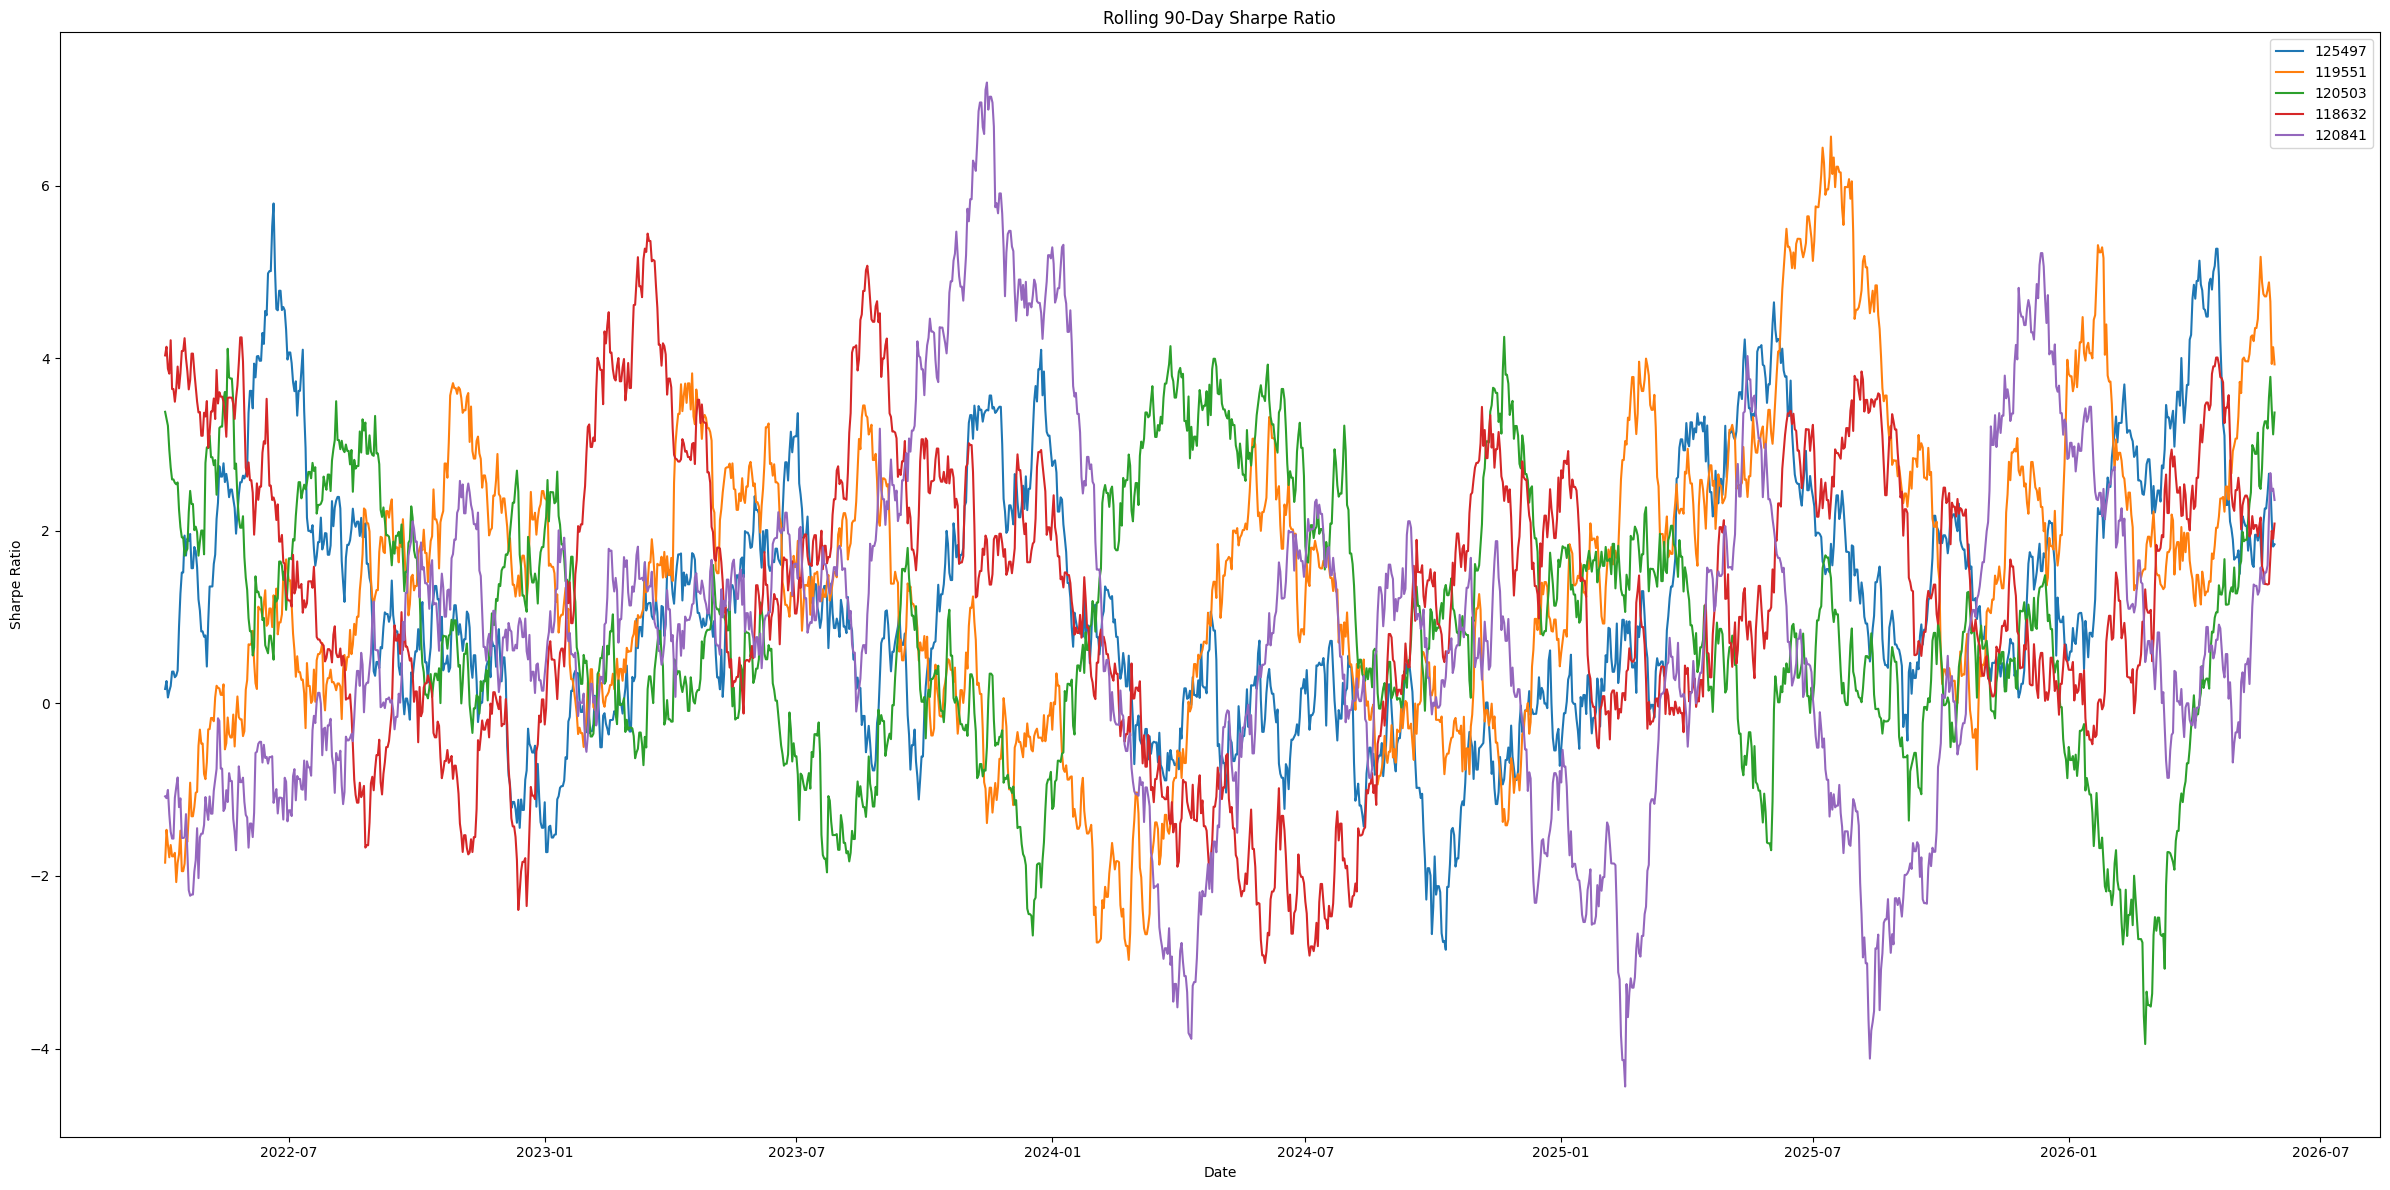

In [38]:
plt.figure(figsize=(24,12))
for fund in selected_funds:

    temp = nav[
        nav['amfi_code'] == fund
    ]
    plt.plot(
        temp['date'],
        temp['rolling_sharpe'],
        label=fund
    )

plt.title(
    "Rolling 90-Day Sharpe Ratio"
)

plt.xlabel("Date")
plt.ylabel("Sharpe Ratio")

plt.legend()
plt.tight_layout()
plt.savefig(
    wd/"rolling_sharpe_chart.png"
)

plt.show()

In [41]:
#task 3

tx = pd.read_csv(rd/"clean_transactions.csv")

tx['transaction_date'] = pd.to_datetime(
    tx['transaction_date']
)

In [47]:
first_tx = (
    tx.groupby('investor_id')
      ['transaction_date']
      .min()
      .reset_index()
)
first_tx['cohort_year'] = (
    first_tx['transaction_date']
    .dt.year
)
tx = tx.merge(
    first_tx[
        ['investor_id','cohort_year']
    ],
    on='investor_id',
    how='left'
)

In [53]:
sip = tx[
    tx['transaction_type'] == 'SIP'
]
avg_sip = (
    sip.groupby('cohort_year')
       ['amount_inr']
       .mean()
       .reset_index()
)
avg_sip

,cohort_year,amount_inr
0,2024,10996.885825
1,2025,13505.209581


In [55]:
investments = tx[
    tx['transaction_type']
    != 'Redemption'
]
total_invested = (
    investments.groupby('cohort_year')
               ['amount_inr']
               .sum()
               .reset_index()
)
total_invested

,cohort_year,amount_inr
0,2024,2258062304
1,2025,18992635


In [57]:
fund_pref = (
    tx.groupby(
        ['cohort_year','amfi_code']
    )
    .size()
    .reset_index(name='transactions')
)
top_funds = (
    fund_pref.sort_values(
        'transactions',
        ascending=False
    )
    .groupby('cohort_year')
    .head(1)
)
top_funds

,cohort_year,amfi_code,transactions
35,2024,148568,874
67,2025,120507,12


In [64]:
cohort_analysis = (
    avg_sip
    .merge(total_invested,
           on='cohort_year')
    .merge(top_funds,
           on='cohort_year')
)
cohort_analysis.to_csv(wd/'cohort_analysis.csv',index=False)

In [65]:
#task 4
sip = tx[tx['transaction_type'] == 'SIP'].copy()

sip = sip.sort_values(['investor_id', 'transaction_date'])

sip['gap_days'] = (
    sip.groupby('investor_id')['transaction_date']
       .diff()
       .dt.days
)

sip_continuity = (
    sip.groupby('investor_id')
       .agg(
           num_sip_transactions=('transaction_date', 'count'),
           avg_gap_days=('gap_days', 'mean')
       )
       .reset_index()
)

sip_continuity = sip_continuity[
    sip_continuity['num_sip_transactions'] >= 6
]

sip_continuity['risk_status'] = sip_continuity['avg_gap_days'].apply(
    lambda x: 'At Risk' if x > 35 else 'Active'
)

sip_continuity.to_csv(
    wd/'sip_continuity.csv',
    index=False
)

print(sip_continuity.head())
print("\nAt Risk Investors:",
      (sip_continuity['risk_status'] == 'At Risk').sum())

   investor_id  num_sip_transactions  avg_gap_days risk_status
3    INV000004                     6     85.400000     At Risk
7    INV000008                     6     70.400000     At Risk
9    INV000010                     6     64.800000     At Risk
10   INV000011                     7     40.166667     At Risk
11   INV000012                     8     57.000000     At Risk

At Risk Investors: 1332


In [ ]:
# task 5 in different file

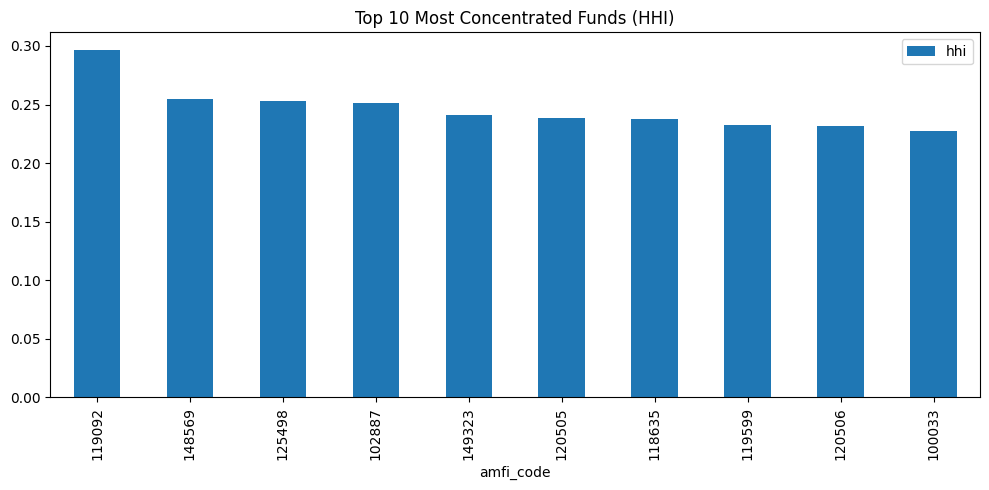

    amfi_code       hhi concentration
5      102886  0.124020   Diversified
25     120843  0.136206   Diversified
15     119551  0.142491   Diversified
14     119095  0.159582      Moderate
9      118634  0.160299      Moderate
    amfi_code       hhi concentration
11     119092  0.296769  Concentrated
30     148569  0.254992  Concentrated
27     125498  0.253155  Concentrated
6      102887  0.251383  Concentrated
32     149323  0.241077      Moderate


In [74]:
#task 6
portfolio = pd.read_csv(rd/"clean_portfoilio.csv")

sector_weights = (
    portfolio.groupby(['amfi_code', 'sector'])['weight_pct']
             .sum()
             .reset_index()
)

sector_hhi = (
    sector_weights.groupby('amfi_code')['weight_pct']
                  .apply(lambda x: ((x / 100) ** 2).sum())
                  .reset_index(name='hhi')
)

sector_hhi['concentration'] = pd.cut(
    sector_hhi['hhi'],
    bins=[0, 0.15, 0.25, 1],
    labels=['Diversified', 'Moderate', 'Concentrated']
)

sector_hhi.to_csv(wd/'sector_hhi.csv', index=False)

sector_hhi.sort_values('hhi', ascending=False).head(10).plot(
    x='amfi_code',
    y='hhi',
    kind='bar',
    figsize=(10,5)
)

plt.title('Top 10 Most Concentrated Funds (HHI)')
plt.tight_layout()
plt.savefig(wd/'sector_hhi_chart.png')
plt.show()

print(sector_hhi.sort_values('hhi').head())
print(sector_hhi.sort_values('hhi',ascending=False).head())

# insights

1. 101207 amfi has highest var with -0.023915
2. cohort 2025 invests more than 2024
3. top fund for 2024 cohort is 148568 while	2025 cohort is 120507
5. there are 1332 investors at risk with INV000004 at highest risk of 84 days between payment
6. 119092 has highest concentrated portfolio with hii= 0.296769 and 102886 lowest with hhi= 0.124020

